In [ ]:
# Welcome to this Noteebook
# This NoteBook is inspired by the book "Hands-on Machine Learning with Scikit-Learn, Keras & TensorFlow"
# This Note book Fine Tune some of the models and finally used the stacking Regressor.

In [ ]:
import pandas as pd
import numpy as np

In [2]:
path = "C:/Users/Amrit Raj/Downloads/housing_data.csv"
housing_data = pd.read_csv(path)

In [3]:
housing_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
housing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


<Axes: xlabel='longitude', ylabel='latitude'>

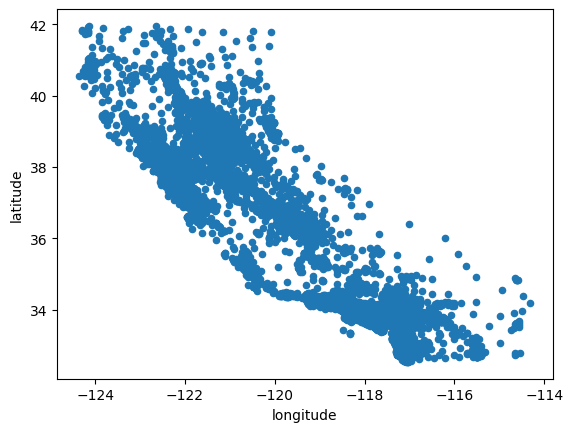

In [6]:
housing_data.plot(kind='scatter', x='longitude', y='latitude')

<Axes: xlabel='longitude', ylabel='latitude'>

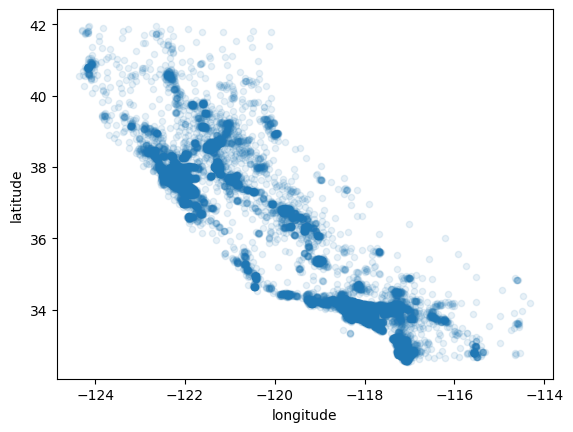

In [7]:
housing_data.plot(kind='scatter', x='longitude', y='latitude', alpha=0.1)

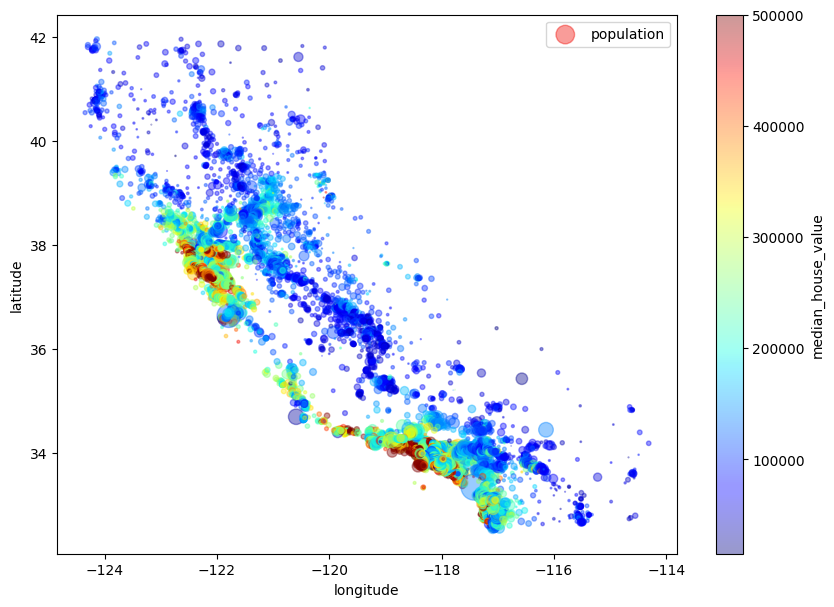

In [8]:
import matplotlib.pyplot as plt
housing_data.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
s=housing_data["population"]/100, label="population", figsize=(10,7),
c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,)
plt.legend()

In [9]:
corr_matrix = housing_data.corr(numeric_only=True)
corr_matrix['median_income'].sort_values(ascending = False)

median_income         1.000000
median_house_value    0.688075
total_rooms           0.198050
households            0.013033
population            0.004834
total_bedrooms       -0.007723
longitude            -0.015176
latitude             -0.079809
housing_median_age   -0.119034
Name: median_income, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

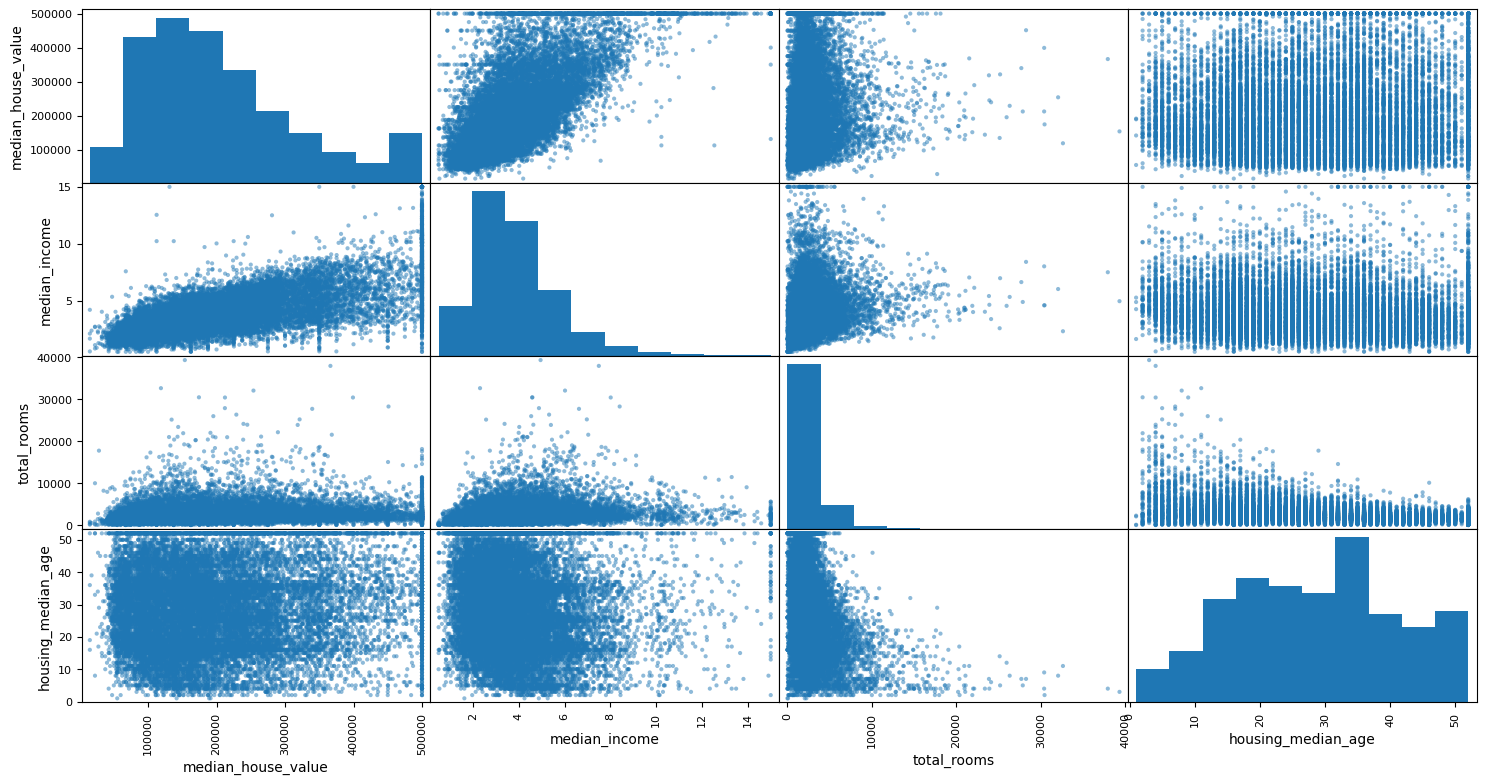

In [10]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing_data[attributes], figsize=(18,9))

In [11]:
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [12]:
housing_data['rooms_per_household'] = housing_data['total_rooms']          / housing_data['households']
housing_data["bedrooms_ratio"] = housing_data['total_bedrooms']           /  housing_data['total_rooms'] 
housing_data["people_per_house"] = housing_data["population"]            /   housing_data["households"]
housing_data['bedrooms_per_household'] = housing_data['total_bedrooms'] /    housing_data['households']

In [13]:
corr_matrix=housing_data.corr(numeric_only= True)
corr_matrix['median_income'].sort_values(ascending=False)

median_income             1.000000
median_house_value        0.688075
rooms_per_household       0.326895
total_rooms               0.198050
people_per_house          0.018766
households                0.013033
population                0.004834
total_bedrooms           -0.007723
longitude                -0.015176
bedrooms_per_household   -0.062299
latitude                 -0.079809
housing_median_age       -0.119034
bedrooms_ratio           -0.615661
Name: median_income, dtype: float64

In [14]:
housing_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   longitude               20640 non-null  float64
 1   latitude                20640 non-null  float64
 2   housing_median_age      20640 non-null  float64
 3   total_rooms             20640 non-null  float64
 4   total_bedrooms          20433 non-null  float64
 5   population              20640 non-null  float64
 6   households              20640 non-null  float64
 7   median_income           20640 non-null  float64
 8   median_house_value      20640 non-null  float64
 9   ocean_proximity         20640 non-null  str    
 10  rooms_per_household     20640 non-null  float64
 11  bedrooms_ratio          20433 non-null  float64
 12  people_per_house        20640 non-null  float64
 13  bedrooms_per_household  20433 non-null  float64
dtypes: float64(13), str(1)
memory usage: 2.2 MB


<Axes: >

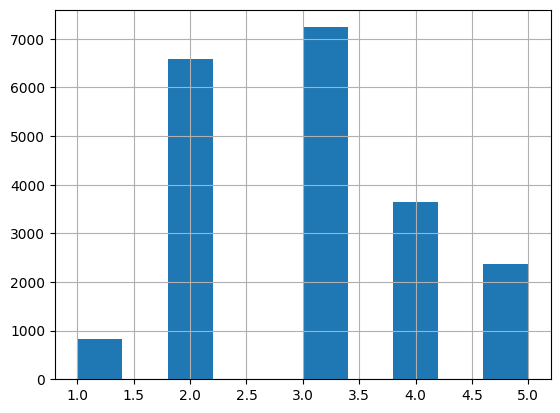

In [15]:
housing_data["income_cat"] = pd.cut(housing_data["median_income"],  bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels= [1,2,3,4,5])
housing_data["income_cat"].hist()

<Axes: >

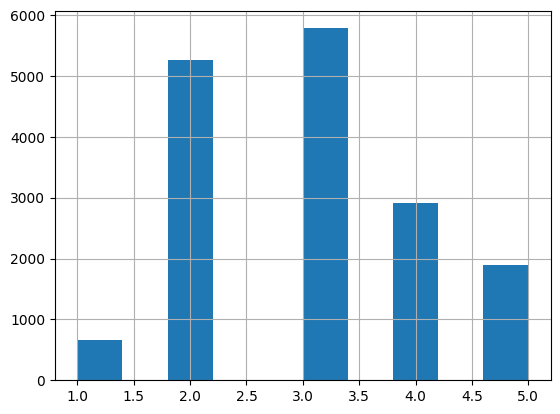

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
spliter =  StratifiedShuffleSplit(n_splits=1, traizein_s = 0.2, random_state=42)
for test_index, train_index in spliter.split(housing_data, housing_data['income_cat']):
    strat_test_set= housing_data.iloc[test_index]
    strat_train_set = housing_data.iloc[train_index]
strat_train_set["income_cat"].hist()

In [17]:
strat_train_set.drop('income_cat', axis=1, inplace=True)
strat_test_set.drop('income_cat', axis=1, inplace = True)
strat_test_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_ratio,people_per_house,bedrooms_per_household
13678,-117.24,34.04,5.0,1775.0,234.0,726.0,222.0,7.9780,223900.0,INLAND,7.995495,0.131831,3.270270,1.054054
236,-122.20,37.79,49.0,882.0,195.0,737.0,210.0,2.6667,122000.0,NEAR BAY,4.200000,0.221088,3.509524,0.928571
12662,-121.42,38.50,24.0,7740.0,1539.0,4333.0,1397.0,3.0250,87900.0,INLAND,5.540444,0.198837,3.101646,1.101646
7021,-118.10,33.98,34.0,1357.0,310.0,1042.0,287.0,3.4083,156700.0,<1H OCEAN,4.728223,0.228445,3.630662,1.080139
4934,-118.27,34.00,40.0,2099.0,599.0,2311.0,529.0,1.8520,101500.0,<1H OCEAN,3.967864,0.285374,4.368620,1.132325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15606,-116.62,32.86,18.0,4115.0,847.0,2032.0,745.0,4.0159,169100.0,<1H OCEAN,5.523490,0.205832,2.727517,1.136913
14790,-117.12,32.56,20.0,2524.0,682.0,1819.0,560.0,2.9286,257700.0,NEAR OCEAN,4.507143,0.270206,3.248214,1.217857
20510,-121.54,38.59,29.0,2242.0,493.0,1481.0,478.0,2.0781,74800.0,INLAND,4.690377,0.219893,3.098326,1.031381
11845,-120.74,39.90,23.0,1017.0,218.0,387.0,152.0,2.2656,88200.0,INLAND,6.690789,0.214356,2.546053,1.434211


In [18]:
housing_labels = strat_train_set['median_house_value'].copy()
housing = strat_train_set.drop(['median_house_value'], axis=1)
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_ratio,people_per_house,bedrooms_per_household
553,-122.26,37.77,52.0,2097.0,444.0,915.0,413.0,2.9899,NEAR BAY,5.077482,0.211731,2.215496,1.075061
7219,-118.16,34.02,35.0,1734.0,493.0,2053.0,508.0,2.1442,<1H OCEAN,3.413386,0.284314,4.041339,0.970472
8204,-118.16,33.78,14.0,1709.0,558.0,1939.0,520.0,1.9808,NEAR OCEAN,3.286538,0.326507,3.728846,1.073077
15571,-116.95,32.96,18.0,2087.0,353.0,992.0,329.0,4.5000,<1H OCEAN,6.343465,0.169142,3.015198,1.072948
7830,-118.15,33.91,38.0,901.0,205.0,760.0,208.0,2.9643,<1H OCEAN,4.331731,0.227525,3.653846,0.985577
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3480,-118.52,34.29,28.0,2272.0,320.0,868.0,312.0,7.7464,<1H OCEAN,7.282051,0.140845,2.782051,1.025641
5158,-118.28,33.96,42.0,1206.0,304.0,1167.0,250.0,1.6150,<1H OCEAN,4.824000,0.252073,4.668000,1.216000
18904,-122.27,38.12,45.0,4423.0,1001.0,2109.0,874.0,2.6937,NEAR BAY,5.060641,0.226317,2.413043,1.145309
19267,-122.74,38.44,17.0,2287.0,497.0,1240.0,493.0,3.5845,<1H OCEAN,4.638945,0.217315,2.515213,1.008114


In [19]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.metrics.pairwise import rbf_kernel
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10,  gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
    
    def fit(self, X, y = None, sample_weight = None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10,
                            random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)


In [20]:
cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy= 'most_frequent')), 
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
                        ])
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy= 'median')), 
    ('scaler', StandardScaler())
                ])
log_pipeline = Pipeline([
    ('log_pipeline_imputer', SimpleImputer(strategy="median")),
    ('log_transformer', FunctionTransformer(np.log, feature_names_out="one-to-one")),
    ('log_pipeline_scaler', StandardScaler())
    ])


In [21]:
preprocessing = ColumnTransformer([
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=num_pipeline) 

In [22]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 25)

In [23]:
from sklearn.linear_model import LinearRegression
lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...), ('geo', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: float, default=0.3I

In [24]:
y_pred = lin_reg.predict(housing)
rmse= root_mean_squared_error(y_pred, housing_labels)
rmse

67975.89488826075

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=42))
forest_rmse = cross_val_score(forest_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10, n_jobs=-1)


In [26]:
forest_rmse = -forest_rmse
pd.Series(forest_rmse).describe()

count       10.000000
mean     47600.126253
std       2026.434771
min      43412.290957
25%      46797.287338
50%      47785.070794
75%      49111.852259
max      50187.470356
dtype: float64

In [27]:
forest_reg.fit(housing, housing_labels)
housing_prediction = forest_reg.predict(housing)
forest_rmse = root_mean_squared_error(housing_labels, housing_prediction)
forest_rmse

17701.03963158557

In [28]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])
param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50),
                  'random_forest__max_features': randint(low=2, high=20)}
rnd_forest_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1)
rnd_forest_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__n_clusters': <scipy.stats....0020648813A10>, 'random_forest__max_features': <scipy.stats....0020648887C50>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that

In [29]:
final_model = rnd_forest_search.best_estimator_  
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.01, 0.01, 0.01, 0.01, 0.2 , 0.03, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.  , 0.01, 0.01, 0.02, 0.01, 0.01, 0.01, 0.01, 0.  , 0.01, 0.01,
       0.02, 0.  , 0.01, 0.01, 0.01, 0.03, 0.02, 0.02, 0.02, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.07, 0.  , 0.  , 0.  ,
       0.01, 0.05, 0.07, 0.05, 0.01])

In [30]:
sorted(zip(feature_importances,
           final_model["preprocessing"].get_feature_names_out()),
           reverse=True)

[(np.float64(0.19921477873111054), 'log__median_income'),
 (np.float64(0.07276106532380744), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.07024219091010817), 'remainder__bedrooms_ratio'),
 (np.float64(0.05186777669880469), 'remainder__people_per_house'),
 (np.float64(0.04922488394503203), 'remainder__rooms_per_household'),
 (np.float64(0.027898039067740476), 'geo__Cluster 22 similarity'),
 (np.float64(0.027064906108623662), 'geo__Cluster 0 similarity'),
 (np.float64(0.02255816208652948), 'geo__Cluster 24 similarity'),
 (np.float64(0.020936843906722107), 'geo__Cluster 23 similarity'),
 (np.float64(0.01973682627219452), 'geo__Cluster 9 similarity'),
 (np.float64(0.018006896724071454), 'geo__Cluster 17 similarity'),
 (np.float64(0.01649891969636466), 'geo__Cluster 25 similarity'),
 (np.float64(0.015463962606618394), 'geo__Cluster 32 similarity'),
 (np.float64(0.014148651256031127), 'geo__Cluster 42 similarity'),
 (np.float64(0.013827736954154022), 'geo__Cluster 35 similarity'),
 (np.flo

In [31]:
strat_test_set
y_test = strat_test_set['median_house_value']
testing_data=strat_test_set.copy()

In [32]:
testing_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_ratio,people_per_house,bedrooms_per_household
13678,-117.24,34.04,5.0,1775.0,234.0,726.0,222.0,7.9780,223900.0,INLAND,7.995495,0.131831,3.270270,1.054054
236,-122.20,37.79,49.0,882.0,195.0,737.0,210.0,2.6667,122000.0,NEAR BAY,4.200000,0.221088,3.509524,0.928571
12662,-121.42,38.50,24.0,7740.0,1539.0,4333.0,1397.0,3.0250,87900.0,INLAND,5.540444,0.198837,3.101646,1.101646
7021,-118.10,33.98,34.0,1357.0,310.0,1042.0,287.0,3.4083,156700.0,<1H OCEAN,4.728223,0.228445,3.630662,1.080139
4934,-118.27,34.00,40.0,2099.0,599.0,2311.0,529.0,1.8520,101500.0,<1H OCEAN,3.967864,0.285374,4.368620,1.132325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15606,-116.62,32.86,18.0,4115.0,847.0,2032.0,745.0,4.0159,169100.0,<1H OCEAN,5.523490,0.205832,2.727517,1.136913
14790,-117.12,32.56,20.0,2524.0,682.0,1819.0,560.0,2.9286,257700.0,NEAR OCEAN,4.507143,0.270206,3.248214,1.217857
20510,-121.54,38.59,29.0,2242.0,493.0,1481.0,478.0,2.0781,74800.0,INLAND,4.690377,0.219893,3.098326,1.031381
11845,-120.74,39.90,23.0,1017.0,218.0,387.0,152.0,2.2656,88200.0,INLAND,6.690789,0.214356,2.546053,1.434211


In [33]:
testing_data.drop('median_house_value', axis=1, inplace=True)
x_test = testing_data

In [34]:

final_predictions = final_model.predict(x_test)
final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

40078.194418495055


In [35]:
from scipy import stats
def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = stats.bootstrap([squared_errors], rmse,
                              confidence_level=confidence, random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval
rmse_lower, rmse_upper

(np.float64(38247.77594903411), np.float64(42334.91209347668))

In [36]:
from sklearn.svm import SVR
from scipy.stats import loguniform,expon
param_grid = {
        'svr__kernel': ['linear', 'rbf'],
        'svr__C': loguniform(20, 200_000),
        'svr__gamma': expon(scale=1.0),
    }
svr_pipeline = make_pipeline(preprocessing, SVR())
rnd_search = RandomizedSearchCV(svr_pipeline,
                                param_distributions=param_grid,
                                n_iter=50, cv=3,
                                scoring='neg_root_mean_squared_error',
                                random_state=42, n_jobs = -1)

rnd_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svr__C': <scipy.stats....00206578F0C20>, 'svr__gamma': <scipy.stats....00206488865D0>, 'svr__kernel': ['linear', 'rbf']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can 

In [37]:
rnd_search.best_params_

{'svr__C': np.float64(157055.10989448498),
 'svr__gamma': np.float64(0.26497040005002437),
 'svr__kernel': 'rbf'}

In [38]:
svr_rnd_search_rmse = -rnd_search.best_score_
svr_rnd_search_rmse

np.float64(53694.72583722708)

In [39]:
# rnd_forest is the final estimator followed by the svr and linear regression

In [41]:
from sklearn.ensemble import StackingRegressor

base_models = [
    ('lin_regressor', lin_reg), 
    ('svr_tuned', rnd_search), 
    ('rf_tuned', rnd_forest_search)
]
stacking_ensemble = StackingRegressor( estimators=base_models, final_estimator=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42), 
                  cv=5, n_jobs=-1)
stacking_ensemble.fit(housing, housing_labels)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('lin_regressor', ...), ('svr_tuned', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",RandomForestR...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...), ('geo', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropp

In [42]:
y_pred = stacking_ensemble.predict(x_test)
root_mean_squared_error(y_test, y_pred)


40049.850975944864

In [43]:
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import uniform, randint
gbrt = make_pipeline(preprocessing, GradientBoostingRegressor(random_state=42))

param_grid = {
    'gradientboostingregressor__n_estimators' : randint(100,600),
    'gradientboostingregressor__learning_rate': uniform(0.01,0.2),
    'gradientboostingregressor__max_depth' : randint(3,8),
    'gradientboostingregressor__subsample' : uniform(0.6, 0.4),
    'gradientboostingregressor__min_samples_split' : randint(2,11)
}
grb_random_search = RandomizedSearchCV(estimator=gbrt, param_distributions= param_grid, cv=3, scoring='neg_root_mean_squared_error', random_state=42, n_jobs = -1
                                       )
grb_random_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'gradientboostingregressor__learning_rate': <scipy.stats....0020657924D70>, 'gradientboostingregressor__max_depth': <scipy.stats....0020658C80E50>, 'gradientboostingregressor__min_samples_split': <scipy.stats....0020658BCCAE0>, 'gradientboostingregressor__n_estimators': <scipy.stats....0020658C810F0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold`

In [44]:
grb_random_search.best_params_

{'gradientboostingregressor__learning_rate': np.float64(0.08997219434305109),
 'gradientboostingregressor__max_depth': 6,
 'gradientboostingregressor__min_samples_split': 4,
 'gradientboostingregressor__n_estimators': 463,
 'gradientboostingregressor__subsample': np.float64(0.8056937753654446)}

In [45]:
y_pred = grb_random_search.predict(x_test)
root_mean_squared_error(y_test, y_pred)


43549.41214023616

In [46]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

base_models = [
    ('gradient_boost', grb_random_search), 
    ('svr_tuned', rnd_search), 
    ('rf_tuned', rnd_forest_search)
]
stacking_ensemble = StackingRegressor( estimators=base_models, final_estimator=RidgeCV(), 
                  cv=5, n_jobs=-1)
stacking_ensemble.fit(housing, housing_labels)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('gradient_boost', ...), ('svr_tuned', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",RidgeCV()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...), ('geo', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'d

In [47]:
y_pred = stacking_ensemble.predict(x_test)
root_mean_squared_error(y_test, y_pred)

39807.15598312885